<!-- config-banner -->
# DINO 1° forward — 200-year spin-up

**`visc2x`** — 200 yr (73200 d) from rest (`nIter0=0`); `viscAhDfile` = `viscAhZfile` = `dino_viscAhD_2p00.bin`, i.e. **2× the reference viscosity**, set through `PARM05`. Run 28463.


## Retired: the two 200-year attempts that crashed (2026-09-03)

Two earlier spin-ups from rest failed before this configuration completed. Both
notebooks and both runs are gone — the notebooks to
`~/trash/Proj_ImPACTS/analyses/DINO_1deg/02_forward/00_archive/`, the runs in
the scratch consolidation — so the record is here:

| Attempt | Run | Reached | Setting |
| --- | --- | --- | --- |
| `viscD2x_Zref` | 19369 | **126.3 of 200 yr** | `viscAhDfile` at 2× reference but `viscAhZfile` left at the reference field — a *mixed* setting |
| `viscGrid1p8e-2` | 28452 | **13 of 200 yr** | scalar `viscAhGrid = 1.8E-2` in `PARM01`, `PARM05` files commented out |
| `visc2x` (this notebook) | 30983 | **200 of 200 yr** | both `viscAhDfile` and `viscAhZfile` at `dino_viscAhD_2p00.bin` |

Raising `viscAhZ` to 2× as well is what turned the 126-year crash into a run
that completed, which is why `visc2x` and `viscD2x_Zref` are kept as distinct
tokens throughout this project.

**Run 19369 was also the only source of the 50-year pickup** (`nIter0=878400`)
and crashed run 18277 the only source of the 70-year one (`nIter0=1229760`).
Both are gone; this run's 2 402 pickups now cover every anchor, so a
`from50yrPk` or `from70yrPk` start is a `visc2x` state today, not the
`viscD2x_Zref` state those tags originally meant.


In [37]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


%load_ext autoreload loads the Jupyter autoreload extension, and %autoreload 2 automatically reloads all imported Python modules before each cell runs so changes in .py files take effect without restarting the kernel.

In [38]:
from dinocean.neverworld2.loader import *
from dinocean.neverworld2.plotter import *
import numpy as np
import xarray as xr
from pathlib import Path
import glob
import xmitgcm

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import warnings; warnings.filterwarnings("ignore")

In [39]:
## Use the following commands to know where the package dinoocean is installed

# import dinocean
# dinocean.__path__

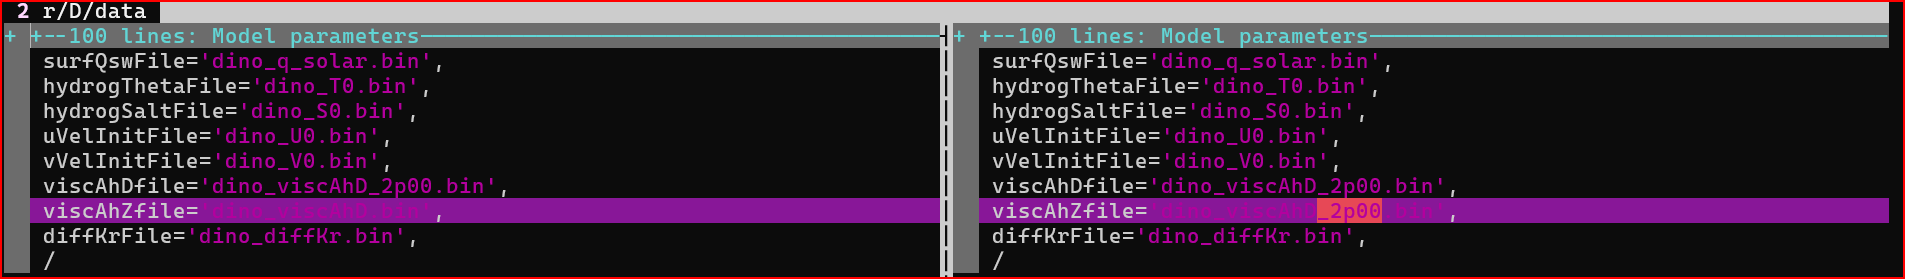

The left configuration crashed after 126 years (the configuration which gave me the longest run). This notebook explore the right configuration

In [40]:
# -------------------------------
# User inputs
# -------------------------------
run_dir = Path("/scratch2/tshahriar/DINO_1deg_outputs/runs/forward/spinup_200yr_visc2x/"
               "DINO_1deg_frd_200yr_from_rest_visc2x_run30983/")
grid_dir = run_dir  # change if your grid files live elsewhere

prefix = ["dynDiag", "surfDiag", "atmDiag", "viscDiag"]
ref = np.datetime64("2000-01-01T00:00:00")
delta_t = 1800.0

# Analysis outputs are written into the run directory on scratch, not the repo
FIG_DIR = run_dir / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


In [41]:
run_dir

PosixPath('/scratch2/tshahriar/DINO_1deg_frd_runs/runs_prod/DINO_1deg_frd_200yr_from_rest_visc2x_run28463')

In [42]:
d_entire = DINOLoader(
    run_dir=str(run_dir),          # Experiment output directory
    ref_date=ref,
    prefix=prefix,    
    niters=None,                # Number of diagnostic timesteps to load
    iters_type='last',        
    delta_t=delta_t            # Model timestep in seconds (must match MITgcm deltaT)
)

In [43]:
# DINOPlotter(d_entire).plot_psi()

In [44]:
d_last10y = DINOLoader(
    run_dir=str(run_dir),          # Experiment output directory
    ref_date=ref,
    prefix=prefix,    # Which MITgcm diagnostics to load
    niters=120,                # Number of diagnostic timesteps to load
    iters_type='last',    # Evenly sample timesteps across entire run
    delta_t=delta_t            # Model timestep in seconds (must match MITgcm deltaT)
)

d_last10y

In [45]:
d_last10y.ds

<xarray.Dataset>
Dimensions:   (i: 51, i_g: 51, j: 198, j_g: 198, k: 36, k_u: 36, k_l: 36,
               k_p1: 37, time: 120)
Coordinates: (12/44)
  * i         (i) int64 0 1 2 3 4 5 6 7 8 9 10 ... 41 42 43 44 45 46 47 48 49 50
  * i_g       (i_g) int64 0 1 2 3 4 5 6 7 8 9 ... 41 42 43 44 45 46 47 48 49 50
  * j         (j) int64 0 1 2 3 4 5 6 7 8 ... 190 191 192 193 194 195 196 197
  * j_g       (j_g) int64 0 1 2 3 4 5 6 7 8 ... 190 191 192 193 194 195 196 197
  * k         (k) int64 0 1 2 3 4 5 6 7 8 9 10 ... 26 27 28 29 30 31 32 33 34 35
  * k_u       (k_u) int64 0 1 2 3 4 5 6 7 8 9 ... 26 27 28 29 30 31 32 33 34 35
    ...        ...
    dxF       (j, i) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
    dyF       (j, i) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
    dxV       (j_g, i_g) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
    dyU       (j_g, i_g) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
    iter      (time) int64 dask.array<chunksize=(1,), meta=np.ndarray>
  * time      (time) datetime64[ns] 2190-06-23T12:00:00 ... 2200-06-01
Data variables: (12/19)
    THETA     (time, k, j, i) float32 dask.array<chunksize=(1, 36, 198, 51), meta=np.ndarray>
    SALT      (time, k, j, i) float32 dask.array<chunksize=(1, 36, 198, 51), meta=np.ndarray>
    PHIHYD    (time, k, j, i) float32 dask.array<chunksize=(1, 36, 198, 51), meta=np.ndarray>
    RHOAnoma  (time, k, j, i) float32 dask.array<chunksize=(1, 36, 198, 51), meta=np.ndarray>
    UVEL      (time, k, j, i_g) float32 dask.array<chunksize=(1, 36, 198, 51), meta=np.ndarray>
    VVEL      (time, k, j_g, i) float32 dask.array<chunksize=(1, 36, 198, 51), meta=np.ndarray>
    ...        ...
    oceTAUY   (time, j_g, i) float32 dask.array<chunksize=(1, 198, 51), meta=np.ndarray>
    oceQnet   (time, j, i) float32 dask.array<chunksize=(1, 198, 51), meta=np.ndarray>
    VISCAHZ   (time, k, j_g, i_g) float32 dask.array<chunksize=(1, 36, 198, 51), meta=np.ndarray>
    VISCAHD   (time, k, j, i) float32 dask.array<chunksize=(1, 36, 198, 51), meta=np.ndarray>
    sigma2    (time, k, j, i) float32 dask.array<chunksize=(1, 36, 198, 51), meta=np.ndarray>
    psi_c     (time, j, i) float32 dask.array<chunksize=(1, 198, 50), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    title:        netCDF wrapper of MITgcm MDS binary data
    source:       MITgcm
    history:      Created by calling `open_mdsdataset(grid_dir='/scratch2/tsh...

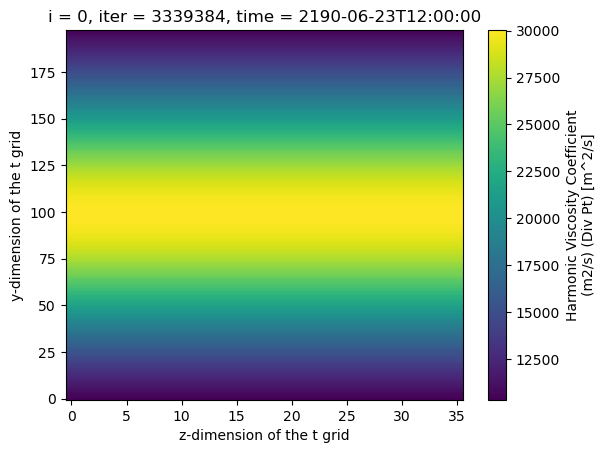

In [46]:
d_last10y.ds.VISCAHD[0][:,:,0].T.plot()

In [47]:
jmid = d_last10y.ds.VISCAHD[0][:,:,0].T.sizes['j'] // 2 #=98

m1_mid = d_last10y.ds.VISCAHD[0][:,:,0].T.isel(j=jmid).mean().compute().item()

print(f"Middle-Y mean VISCAHD : {m1_mid}")

Middle-Y mean VISCAHD : 30023.7109375


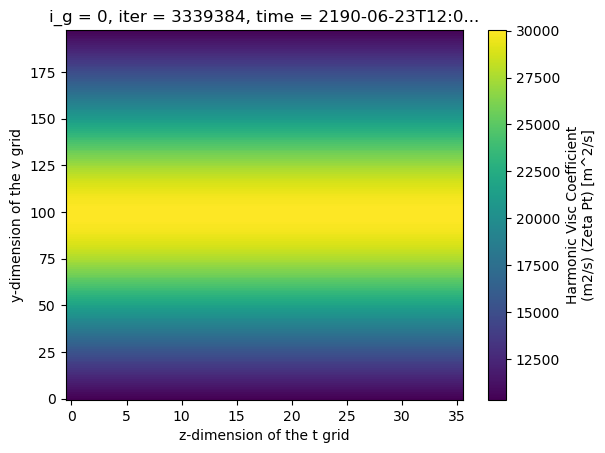

In [48]:
d_last10y.ds.VISCAHZ[0][:,:,0].T.plot()

In [49]:
jmid = d_last10y.ds.VISCAHZ[0][:,:,0].T.sizes['j_g'] // 2 #=98

m1_mid = d_last10y.ds.VISCAHZ[0][:,:,0].T.isel(j_g=jmid).mean().compute().item()

print(f"Middle-Y mean VISCAHZ : {m1_mid}")

Middle-Y mean VISCAHZ : 30023.7109375


In [50]:
# ds = xmitgcm.open_mdsdataset(run_from_pickup, prefix=['surfDiag', 'dynDiag'], geometry='curvilinear', delta_t=1800)
# ds

In [51]:
# ds.THETA.max(ds.hFacC.dims).plot()

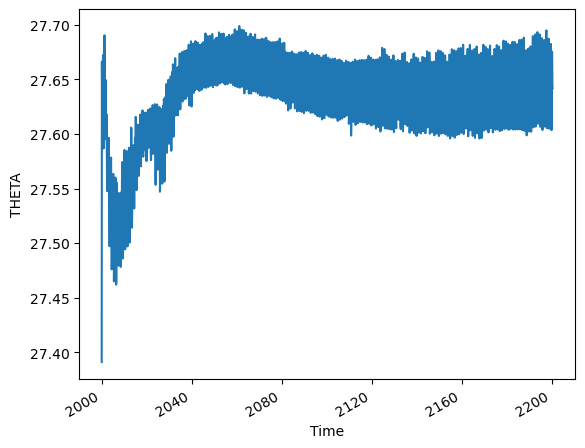

In [52]:
d_entire.ds.THETA.max(d_entire.ds.hFacC.dims).plot()

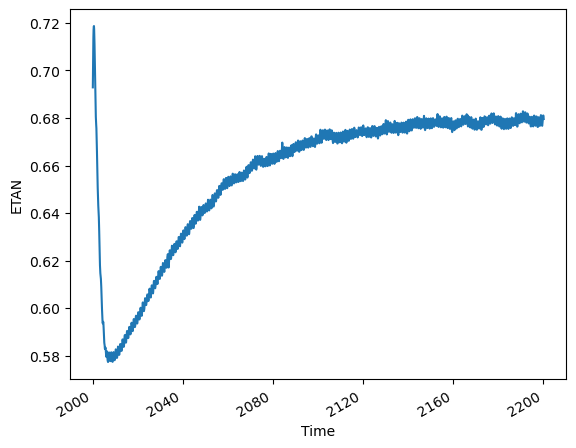

In [53]:
d_entire.ds.ETAN.max(d_entire.ds.hFacC[0].dims).plot()

In [54]:
# d_last10y.ds.ETAN.plot(col='time')

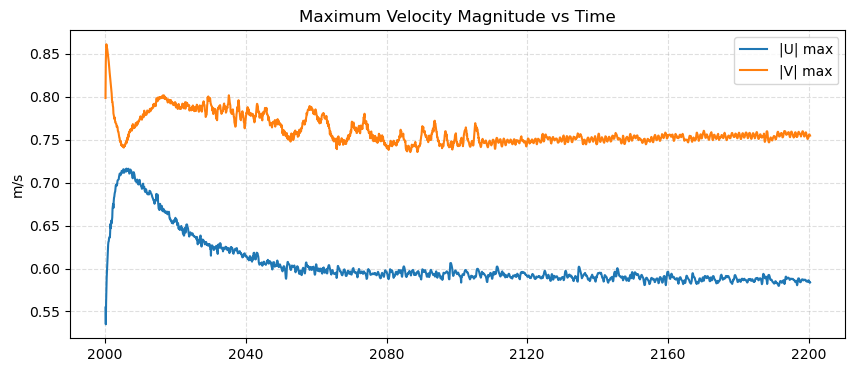

In [55]:
# --- Absolute velocities ---
u_abs = np.abs(d_entire.ds.UVEL)
v_abs = np.abs(d_entire.ds.VVEL)

# --- Spatial dimensions (exclude time) ---
u_dims = [dim for dim in u_abs.dims if dim != "time"]
v_dims = [dim for dim in v_abs.dims if dim != "time"]

# --- Maximum over space ---
u_max = u_abs.max(dim=u_dims)
v_max = v_abs.max(dim=v_dims)

# --- Plot ---
fig, ax = plt.subplots(figsize=(10,4))

ax.plot(d_entire.ds.time, u_max, label="|U| max")
ax.plot(d_entire.ds.time, v_max, label="|V| max")

ax.set_ylabel("m/s")
ax.set_title("Maximum Velocity Magnitude vs Time")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)

plt.show()

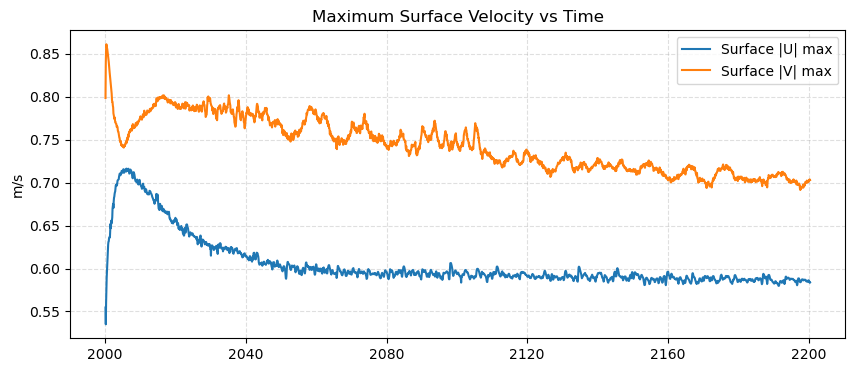

In [56]:
# --- Surface velocities ---
u_surf = d_entire.ds.UVEL.isel(k=0)
v_surf = d_entire.ds.VVEL.isel(k=0)

# --- Absolute value ---
u_abs = np.abs(u_surf)
v_abs = np.abs(v_surf)

# --- Horizontal dimensions ---
u_dims = [dim for dim in u_abs.dims if dim != "time"]
v_dims = [dim for dim in v_abs.dims if dim != "time"]

# --- Max over space ---
u_surf_max = u_abs.max(dim=u_dims)
v_surf_max = v_abs.max(dim=v_dims)

# --- Plot ---
fig, ax = plt.subplots(figsize=(10,4))

ax.plot(d_entire.ds.time, u_surf_max, label="Surface |U| max")
ax.plot(d_entire.ds.time, v_surf_max, label="Surface |V| max")

ax.set_ylabel("m/s")
ax.set_title("Maximum Surface Velocity vs Time")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)

plt.show()

In [57]:
# # --- Compute surface speed ---
# speed_surf = np.sqrt(
#     d_entire.ds.UVEL.isel(k=0)**2 +
#     d_entire.ds.VVEL.isel(k=0)**2
# )

# # --- Horizontal dimensions ---
# speed_surf_dims = [dim for dim in speed_surf.dims if dim != "time"]

# # --- Maximum over space ---
# speed_surf_max = speed_surf.max(dim=speed_surf_dims)

# # --- Plot ---
# fig, ax = plt.subplots(figsize=(10,4))

# ax.plot(d_entire.ds.time, speed_surf_max, linewidth=2)

# ax.set_ylabel("Speed [m s$^{-1}$]")
# ax.set_xlabel("Time")
# ax.set_title("Maximum Surface Speed vs Time")
# ax.grid(True, linestyle="--", alpha=0.4)

# plt.show()

(<Figure size 1000x600 with 2 Axes>,
 <Axes: title={'center': 'MOC Depth Space (Time-Averaged)'}, xlabel='Latitude [$^\\circ$N]', ylabel='Depth [m]'>)

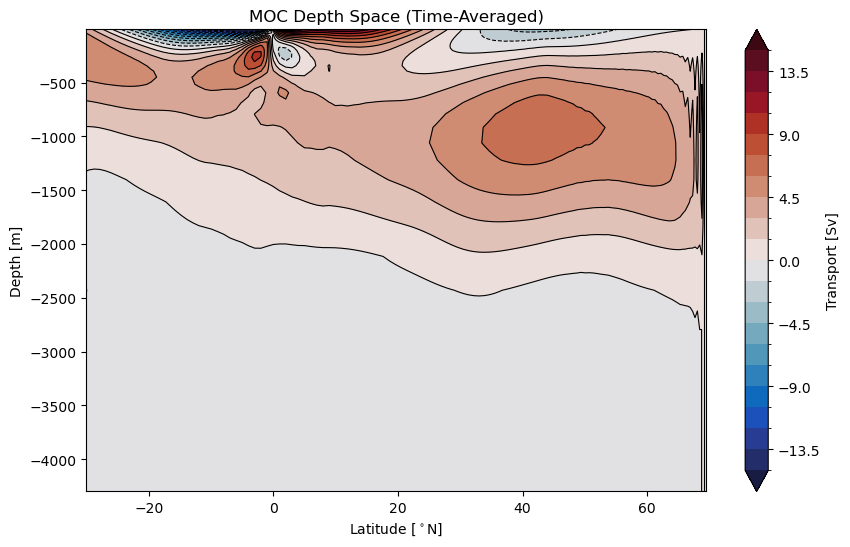

In [58]:
# d_last10y.plot_moc_depth_space(timemean=True)
DINOPlotter(d_last10y).plot_moc_depth_space(timemean=True)

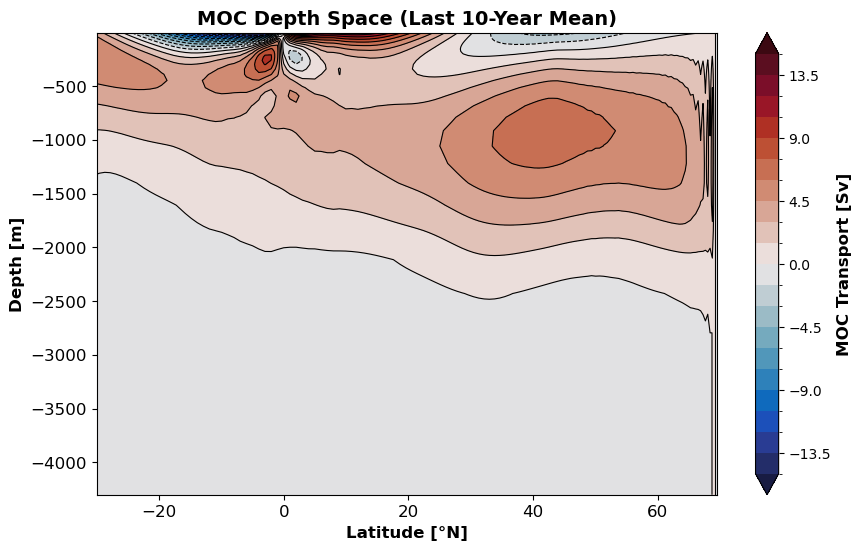

In [23]:
# Create the plot
fig, ax = DINOPlotter(d_last10y).plot_moc_depth_space(timemean=True)

# Axis labels
ax.set_xlabel(
    'Latitude [°N]',
    fontsize=12,
    fontweight='bold'
)

ax.set_ylabel(
    'Depth [m]',
    fontsize=12,
    fontweight='bold'
)

# Colorbar label
cbar = fig.axes[-1]
cbar.set_ylabel(
    'MOC Transport [Sv]',
    fontsize=12,
    fontweight='bold'
)

# Two-line shorter title
ax.set_title(
    'MOC Depth Space (Last 10-Year Mean)',
    fontsize=14,
    fontweight='bold'
)

# Larger tick labels
ax.tick_params(axis='both', labelsize=12)

# # Save figure
# fig.savefig(
#     FIG_DIR / "moc_depth_space.png",
#     dpi=300,
#     bbox_inches='tight'
# )

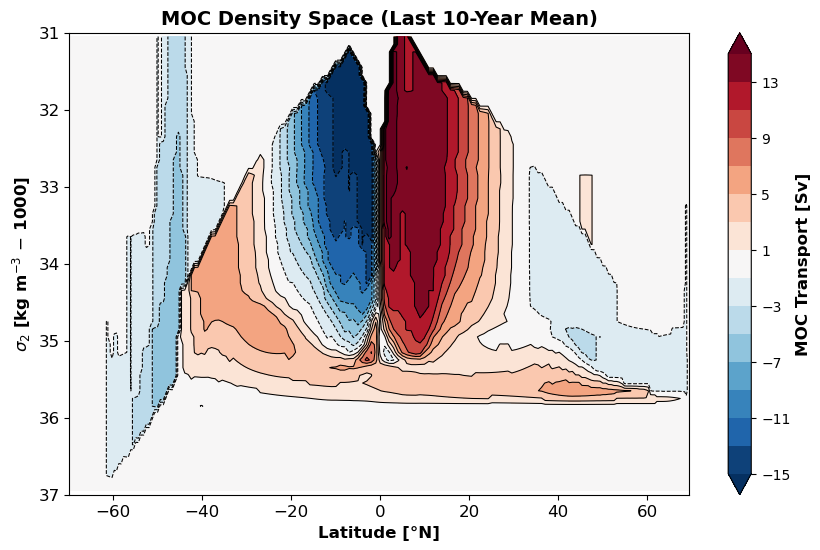

In [63]:
# d_last10y.plot_moc_density_space(timemean=True)

# Create the plot
fig, ax = DINOPlotter(d_last10y).plot_moc_density_space(timemean=True)

# Axis labels
ax.set_xlabel(
    'Latitude [°N]',
    fontsize=12,
    fontweight='bold'
)

ax.set_ylabel(
    r'$\sigma_2$ [kg m$^{-3}$ $-$ 1000]',
    fontsize=12,
    fontweight='bold'
)

# Colorbar label
cbar = fig.axes[-1]
cbar.set_ylabel(
    'MOC Transport [Sv]',
    fontsize=12,
    fontweight='bold'
)

# Two-line shorter title
ax.set_title(
    'MOC Density Space (Last 10-Year Mean)',
    fontsize=14,
    fontweight='bold'
)

# Larger tick labels
ax.tick_params(axis='both', labelsize=12)

# # Save figure
fig.savefig(
     FIG_DIR / "moc_density_space.png",
     dpi=300,
     bbox_inches='tight'
 )

In [25]:
# from dinocean.neverworld2.gif import *
# import os

# # Create a subdirectory inside the run directory for figures
# fig_dir = os.path.join(run_dir, "figures_moc_depth")

# gm = GIFmaker(
#     outdir=fig_dir,        # Save frames in run_dir/figures_moc_depth/
#     prefix="moc_depth",    # Frame filename prefix
#     dpi=150                # Figure resolution
# )

# gm.make_frames(
#     nt=d_last10y.nt,                                   # Number of loaded snapshots
#     frame_func=lambda i: d_last10y.plot_moc_depth_space(index_show=i),
#     stride=1,                                 # Plot every snapshot
# )

# gm.show_slider()

# # Optional: create animated GIF
# # gm.to_gif()

In [26]:
# # d_last10y.plot_psi_fancy(timemean=True)

# DINOPlotter(d_last10y).plot_psi(timemean=True)

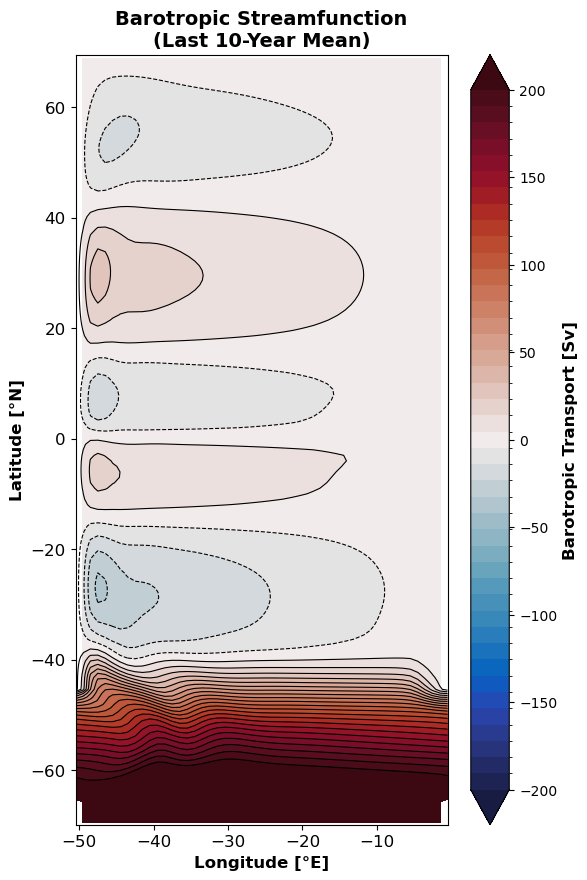

In [27]:
# Create the plot
fig, ax = DINOPlotter(d_last10y).plot_psi(timemean=True)

# Axis labels (bigger + bold)
ax.set_xlabel(
    'Longitude [°E]',
    fontsize=12,
    fontweight='bold'
)

ax.set_ylabel(
    'Latitude [°N]',
    fontsize=12,
    fontweight='bold'
)

# Colorbar label
cbar = fig.axes[-1]
cbar.set_ylabel(
    'Barotropic Transport [Sv]',
    fontsize=12,
    fontweight='bold'
)

# Two-line title
ax.set_title(
    'Barotropic Streamfunction\n(Last 10-Year Mean)',
    fontsize=14,
    fontweight='bold'
)

# Optional: larger tick labels
ax.tick_params(axis='both', labelsize=12)

# # Save figure
# fig.savefig(
#     FIG_DIR / "psi_timemean.png",
#     dpi=300,
#     bbox_inches='tight'
# )

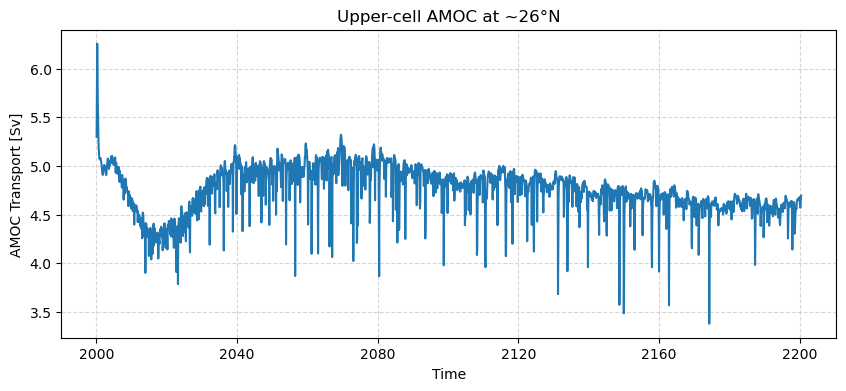

In [28]:
# --- 1) Build MOC (psi_moc) for all loaded times (same math as plot_moc_depth_space) ---
vert_dim = d_entire.vert_dim  # 'k' for curvilinear, else 'Z'

v = d_entire.ds.VVEL  # (time, k, j_g, i)

# Transport in Sv: integrate zonally and over layer thickness + partial cells
transport = (v * d_entire.ds.dxG * d_entire.ds.drF * d_entire.ds.hFacS).sum("i") / 1e6  # (time,k,j_g)

# Streamfunction in depth-space: cumulative sum from surface downward (same as package)
psi_moc = transport.sortby(vert_dim, ascending=True).cumsum(vert_dim)  # (time,k,j_g)

# Attach latitude coordinate to j_g (V-grid latitude)
lat = d_entire.ds.YC.isel(i=0).rename({"j": "j_g"})
psi_moc = psi_moc.assign_coords(YC=lat)

# --- 2) Select latitude closest to 30N ---
target_lat = 26
j_sel = int(np.abs(psi_moc.YC - target_lat).argmin("j_g").values)
lat_sel = float(psi_moc.YC.isel(j_g=j_sel).values)

# --- 3) Restrict to upper 1000 m and take the max over depth ---
# In MITgcm, Z is typically 0 at surface and NEGATIVE downward (meters)
z = d_entire.ds.Z if "Z" in d_entire.ds else d_entire.ds[vert_dim]
upper_mask = (z >= -1000)

psi_upper = psi_moc.where(upper_mask, drop=True)              # keep only z >= -1000 m
amoc_upper_30N = psi_upper.isel(j_g=j_sel).max(vert_dim)      # (time,) in Sv

# --- 4) Plot ---
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(d_entire.ds.time.values, amoc_upper_30N.values)
ax.set_title(f"Upper-cell AMOC at ~{lat_sel:.0f}°N")
ax.set_xlabel("Time")
ax.set_ylabel("AMOC Transport [Sv]")
ax.grid(True, linestyle="--", alpha=0.5)
plt.show()

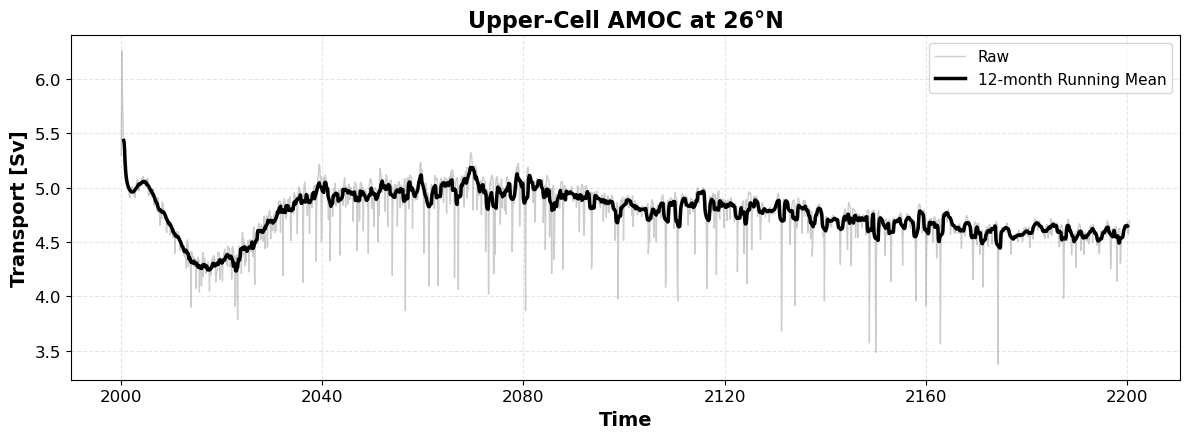

In [29]:
# --- Smooth the time series (optional but recommended) ---
# Example: 12-point rolling mean
amoc_smooth = amoc_upper_30N.rolling(time=12, center=True).mean()

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 4.5))

# Raw signal (light)
ax.plot(
    d_entire.ds.time.values,
    amoc_upper_30N.values,
    color='gray',
    alpha=0.4,
    linewidth=1,
    label='Raw'
)

# Smoothed signal
ax.plot(
    d_entire.ds.time.values,
    amoc_smooth.values,
    color='black',
    linewidth=2.5,
    label='12-month Running Mean'
)

# Labels
ax.set_title(
    f'Upper-Cell AMOC at {lat_sel:.0f}°N',
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel(
    'Time',
    fontsize=14,
    fontweight='bold'
)

ax.set_ylabel(
    'Transport [Sv]',
    fontsize=14,
    fontweight='bold'
)

# Tick styling
ax.tick_params(axis='both', labelsize=12)

# Cleaner grid
ax.grid(True, linestyle='--', alpha=0.3)

# Legend
ax.legend(fontsize=11)

# Tight layout
plt.tight_layout()

# # Save if desired
# fig.savefig(
#     FIG_DIR / "amoc_timeseries.png",
#     dpi=300,
#     bbox_inches='tight'
# )

plt.show()

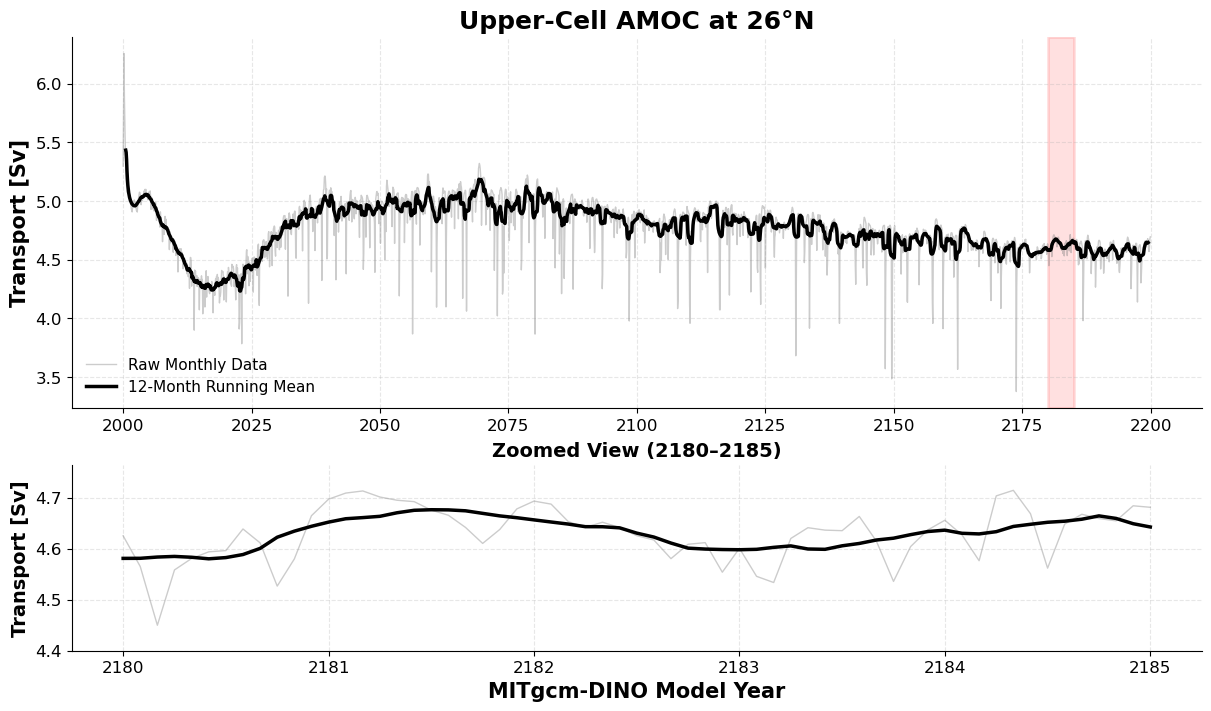

In [30]:
# ---------------------------------------------------------
# Smooth the AMOC time series
# ---------------------------------------------------------
amoc_smooth = amoc_upper_30N.rolling(time=12, center=True).mean()

# ---------------------------------------------------------
# Create MODEL YEAR axis (2000 → 2200)
# ---------------------------------------------------------
nmonths = len(d_entire.ds.time)

model_years = 2000 + np.arange(nmonths) / 12.0

# ---------------------------------------------------------
# Define zoom window
# ---------------------------------------------------------
zoom_start = 2180
zoom_end   = 2185

# ---------------------------------------------------------
# Create figure
# ---------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(12, 7),
    gridspec_kw={'height_ratios': [2, 1]},
    constrained_layout=True
)

# =========================================================
# TOP PANEL — FULL TIME SERIES
# =========================================================

# Raw signal
ax1.plot(
    model_years,
    amoc_upper_30N.values,
    color='gray',
    alpha=0.4,
    linewidth=1,
    label='Raw Monthly Data'
)

# Smoothed signal
ax1.plot(
    model_years,
    amoc_smooth.values,
    color='black',
    linewidth=2.5,
    label='12-Month Running Mean'
)

# Labels
ax1.set_title(
    f'Upper-Cell AMOC at {lat_sel:.0f}°N',
    fontsize=18,
    fontweight='bold'
)

ax1.set_ylabel(
    'Transport [Sv]',
    fontsize=15,
    fontweight='bold'
)

# Grid
ax1.grid(True, linestyle='--', alpha=0.3)

# Styling
ax1.tick_params(axis='both', labelsize=12)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Legend
ax1.legend(fontsize=11, frameon=False)

# ---------------------------------------------------------
# Highlight zoom region
# ---------------------------------------------------------
ymin, ymax = ax1.get_ylim()

rect = Rectangle(
    (zoom_start, ymin),
    zoom_end - zoom_start,
    ymax - ymin,
    linewidth=2,
    edgecolor='red',
    facecolor='red',
    alpha=0.12
)

ax1.add_patch(rect)

# =========================================================
# BOTTOM PANEL — ZOOMED VIEW
# =========================================================

zoom_mask = (model_years >= zoom_start) & (model_years <= zoom_end)

# Raw signal
ax2.plot(
    model_years[zoom_mask],
    amoc_upper_30N.values[zoom_mask],
    color='gray',
    alpha=0.4,
    linewidth=1
)

# Smoothed signal
ax2.plot(
    model_years[zoom_mask],
    amoc_smooth.values[zoom_mask],
    color='black',
    linewidth=2.5
)

# Labels
ax2.set_title(
    f'Zoomed View ({zoom_start}–{zoom_end})',
    fontsize=14,
    fontweight='bold'
)

ax2.set_xlabel(
    'MITgcm-DINO Model Year',
    fontsize=15,
    fontweight='bold'
)

ax2.set_ylabel(
    'Transport [Sv]',
    fontsize=14,
    fontweight='bold'
)

# Grid
ax2.grid(True, linestyle='--', alpha=0.3)

# Styling
ax2.tick_params(axis='both', labelsize=12)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# ---------------------------------------------------------
# Match zoomed y-limits tightly
# ---------------------------------------------------------
zoom_vals = amoc_upper_30N.values[zoom_mask]

ax2.set_ylim(
    zoom_vals.min() - 0.05,
    zoom_vals.max() + 0.05
)

# ---------------------------------------------------------
# Save figure (optional)
# ---------------------------------------------------------
# fig.savefig(
#     FIG_DIR / "amoc_zoomed_timeseries.png",
#     dpi=300,
#     bbox_inches='tight'
# )

plt.show()

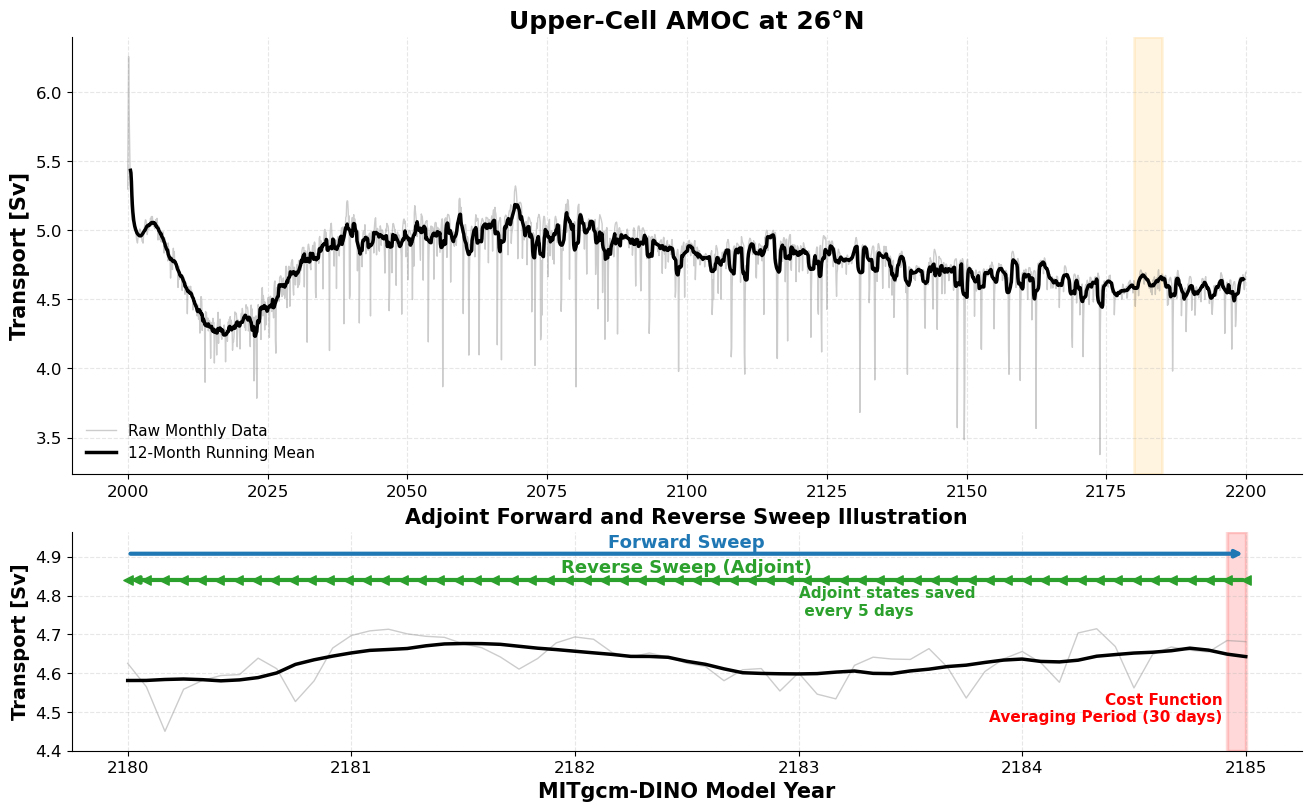

In [31]:
# ---------------------------------------------------------
# Smooth the AMOC time series
# ---------------------------------------------------------
amoc_smooth = amoc_upper_30N.rolling(time=12, center=True).mean()

# ---------------------------------------------------------
# Create MODEL YEAR axis (2000 → 2200)
# ---------------------------------------------------------
nmonths = len(d_entire.ds.time)

model_years = 2000 + np.arange(nmonths) / 12.0

# ---------------------------------------------------------
# Define zoom window
# ---------------------------------------------------------
zoom_start = 2180
zoom_end   = 2185

# ---------------------------------------------------------
# Create figure
# ---------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(13, 8),
    gridspec_kw={'height_ratios': [2, 1]},
    constrained_layout=True
)

# =========================================================
# TOP PANEL — FULL TIME SERIES
# =========================================================

# Raw signal
ax1.plot(
    model_years,
    amoc_upper_30N.values,
    color='gray',
    alpha=0.4,
    linewidth=1,
    label='Raw Monthly Data'
)

# Smoothed signal
ax1.plot(
    model_years,
    amoc_smooth.values,
    color='black',
    linewidth=2.5,
    label='12-Month Running Mean'
)

# Labels
ax1.set_title(
    f'Upper-Cell AMOC at {lat_sel:.0f}°N',
    fontsize=18,
    fontweight='bold'
)

ax1.set_ylabel(
    'Transport [Sv]',
    fontsize=15,
    fontweight='bold'
)

# Grid
ax1.grid(True, linestyle='--', alpha=0.3)

# Styling
ax1.tick_params(axis='both', labelsize=12)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Legend
ax1.legend(fontsize=11, frameon=False)

# ---------------------------------------------------------
# Highlight zoom region
# ---------------------------------------------------------
ymin, ymax = ax1.get_ylim()

rect = Rectangle(
    (zoom_start, ymin),
    zoom_end - zoom_start,
    ymax - ymin,
    linewidth=2,
    edgecolor='orange',
    facecolor='orange',
    alpha=0.12
)

ax1.add_patch(rect)

# =========================================================
# BOTTOM PANEL — ZOOMED VIEW
# =========================================================

zoom_mask = (model_years >= zoom_start) & (model_years <= zoom_end)

x_zoom = model_years[zoom_mask]
y_zoom = amoc_upper_30N.values[zoom_mask]

# Raw signal
ax2.plot(
    x_zoom,
    y_zoom,
    color='gray',
    alpha=0.4,
    linewidth=1
)

# Smoothed signal
ax2.plot(
    x_zoom,
    amoc_smooth.values[zoom_mask],
    color='black',
    linewidth=2.5
)

# ---------------------------------------------------------
# Labels
# ---------------------------------------------------------
ax2.set_title(
    f'Adjoint Forward and Reverse Sweep Illustration',
    fontsize=15,
    fontweight='bold'
)

ax2.set_xlabel(
    'MITgcm-DINO Model Year',
    fontsize=15,
    fontweight='bold'
)

ax2.set_ylabel(
    'Transport [Sv]',
    fontsize=14,
    fontweight='bold'
)

# ---------------------------------------------------------
# Grid / styling
# ---------------------------------------------------------
ax2.grid(True, linestyle='--', alpha=0.3)

ax2.tick_params(axis='both', labelsize=12)

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# ---------------------------------------------------------
# Match zoomed y-limits tightly
# ---------------------------------------------------------
ax2.set_ylim(
    y_zoom.min() - 0.05,
    y_zoom.max() + 0.25
)

# =========================================================
# ADJOINT ILLUSTRATION
# =========================================================

ymin2, ymax2 = ax2.get_ylim()
yrange = ymax2 - ymin2

# ---------------------------------------------------------
# Define y-levels for arrows
# ---------------------------------------------------------
forward_y = ymax2 - 0.10 * yrange
reverse_y = ymax2 - 0.22 * yrange

# ---------------------------------------------------------
# Forward sweep arrow
# ---------------------------------------------------------
ax2.annotate(
    '',
    xy=(zoom_end, forward_y),
    xytext=(zoom_start, forward_y),
    arrowprops=dict(
        arrowstyle='->',
        lw=3,
        color='tab:blue'
    )
)

ax2.text(
    (zoom_start + zoom_end) / 2,
    forward_y + 0.03 * yrange,
    'Forward Sweep',
    color='tab:blue',
    fontsize=13,
    fontweight='bold',
    ha='center'
)

# =========================================================
# COST FUNCTION AVERAGING WINDOW
# =========================================================

# 30 days = 1 month = 1/12 year
cost_width = 30 / 360.0

cost_start = zoom_end - cost_width

cost_rect = Rectangle(
    (cost_start, ymin2),
    cost_width,
    ymax2 - ymin2,
    linewidth=2.5,
    edgecolor='red',
    facecolor='red',
    alpha=0.15
)

ax2.add_patch(cost_rect)

ax2.text(
    cost_start - 0.02,
    ymin2 + 0.12 * yrange,
    'Cost Function\nAveraging Period (30 days)',
    color='red',
    fontsize=11,
    fontweight='bold',
    ha='right',
    va='bottom'
)

# =========================================================
# REVERSE SWEEP ARROW
# =========================================================

# Place reverse arrow slightly lower
reverse_y = ymax2 - 0.22 * yrange

# Arrow starts at END and points backward
ax2.annotate(
    '',
    xy=(zoom_start, reverse_y),     # arrow head (left)
    xytext=(zoom_end, reverse_y),   # arrow tail (right)
    arrowprops=dict(
        arrowstyle='->',
        lw=3,
        color='tab:green'
    )
)

# Label
ax2.text(
    (zoom_start + zoom_end) / 2,
    reverse_y + 0.035 * yrange,
    'Reverse Sweep (Adjoint)',
    color='tab:green',
    fontsize=13,
    fontweight='bold',
    ha='center'
)

# =========================================================
# INTERMEDIATE ADJOINT OUTPUTS
# =========================================================

# Actual dump frequency = 5 days
five_day = 5 / 366.0

# ---------------------------------------------------------
# VISUALIZATION STRATEGY:
# Show only sparse markers to avoid clutter
# (e.g. every ~30 days visually)
# ---------------------------------------------------------

visual_spacing = 30 / 366.0

visual_times = np.arange(
    zoom_end,
    zoom_start,
    -visual_spacing
)

# Draw triangular markers along reverse sweep
ax2.scatter(
    visual_times,
    np.full_like(visual_times, reverse_y),
    marker='<',
    s=45,
    color='tab:green',
    zorder=5
)

# ---------------------------------------------------------
# Add annotation
# ---------------------------------------------------------

sample_t = zoom_end - 0.8

ax2.annotate(
    'Adjoint states saved\n every 5 days',
    xy=(sample_t, reverse_y),
    xytext=(sample_t - 1.2, reverse_y - 0.16 * yrange),
    fontsize=11,
    color='tab:green',
    fontweight='bold'
)

# ---------------------------------------------------------
# Optional save
# ---------------------------------------------------------
# fig.savefig(
#     FIG_DIR / "amoc_adjoint_schematic.png",
#     dpi=300,
#     bbox_inches='tight'
# )

plt.show()

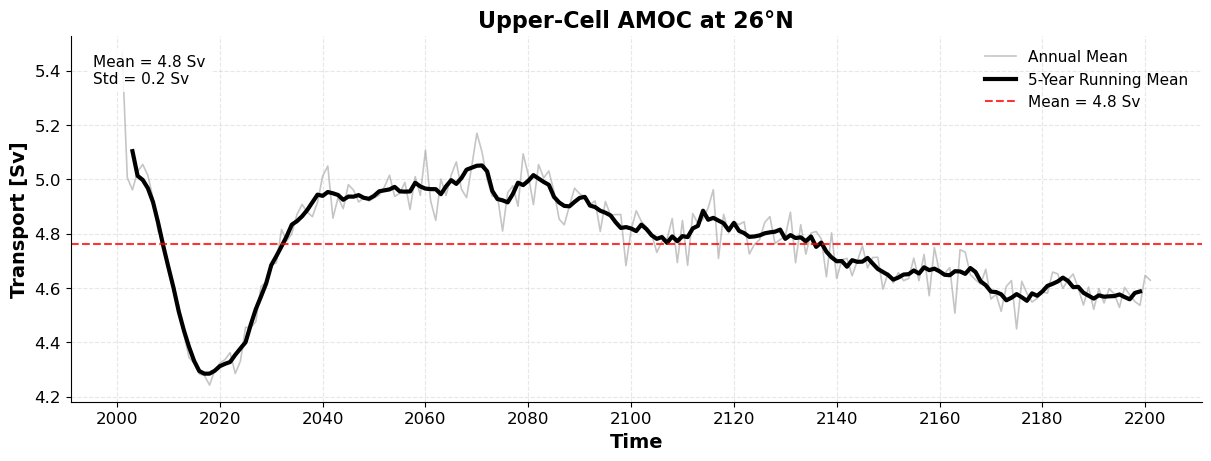

In [32]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ---------------------------------------------------------
# Annual mean AMOC
# ---------------------------------------------------------
amoc_annual = amoc_upper_30N.resample(time='1Y').mean()

# 5-year running mean
amoc_smooth = amoc_annual.rolling(time=5, center=True).mean()

# Mean and std
mean_val = float(amoc_annual.mean().values)
std_val  = float(amoc_annual.std().values)

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------
fig, ax = plt.subplots(
    figsize=(12, 4.5),
    constrained_layout=True
)

# Annual mean (light gray)
ax.plot(
    amoc_annual.time.values,
    amoc_annual.values,
    color='gray',
    alpha=0.45,
    linewidth=1.2,
    label='Annual Mean'
)

# Smoothed curve (main signal)
ax.plot(
    amoc_smooth.time.values,
    amoc_smooth.values,
    color='black',
    linewidth=3,
    label='5-Year Running Mean'
)

# Mean reference line
ax.axhline(
    mean_val,
    linestyle='--',
    linewidth=1.5,
    alpha=0.8,
    color='red',
    label=f'Mean = {mean_val:.1f} Sv'
)

# ---------------------------------------------------------
# Labels and title
# ---------------------------------------------------------
ax.set_title(
    f'Upper-Cell AMOC at {lat_sel:.0f}°N',
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel(
    'Time',
    fontsize=14,
    fontweight='bold'
)

ax.set_ylabel(
    'Transport [Sv]',
    fontsize=14,
    fontweight='bold'
)

# ---------------------------------------------------------
# Axis styling
# ---------------------------------------------------------
ax.tick_params(
    axis='both',
    labelsize=12
)

# Cleaner spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Grid
ax.grid(
    True,
    linestyle='--',
    alpha=0.3
)

# X-axis ticks every 20 years
ax.xaxis.set_major_locator(mdates.YearLocator(20))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# ---------------------------------------------------------
# Statistics box
# ---------------------------------------------------------
ax.text(
    0.02,
    0.95,
    f'Mean = {mean_val:.1f} Sv\nStd = {std_val:.1f} Sv',
    transform=ax.transAxes,
    fontsize=11,
    verticalalignment='top',
    bbox=dict(
        facecolor='white',
        alpha=0.85,
        edgecolor='none'
    )
)

# Legend
ax.legend(
    fontsize=11,
    frameon=False
)

# ---------------------------------------------------------
# Save figure
# ---------------------------------------------------------
# fig.savefig(
#     FIG_DIR / "amoc_timeseries_final.png",
#     dpi=300,
#     bbox_inches='tight'
# )

plt.show()

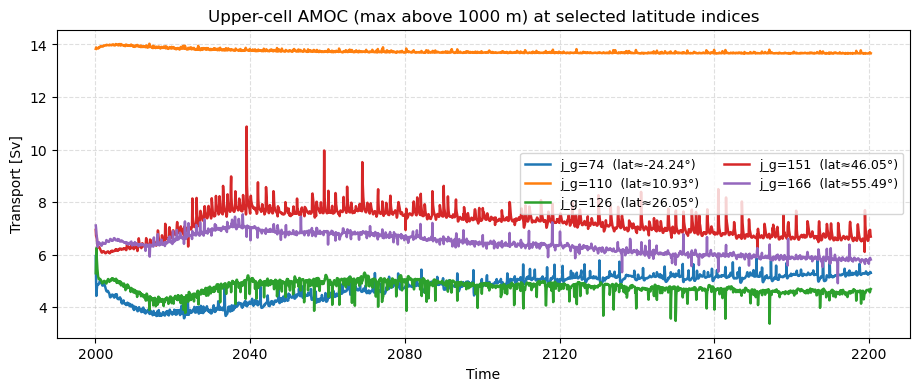

In [33]:
# --- indices you want on the V-grid (j_g) ---
J_list = [74, 110, 126, 151, 166]

vert_dim = d_entire.vert_dim  # 'k' for curvilinear, else 'Z'

# --- build MOC in depth space (same math as plot_moc_depth_space) ---
v = d_entire.ds.VVEL  # (time,k,j_g,i)
transport = (v * d_entire.ds.dxG * d_entire.ds.drF * d_entire.ds.hFacS).sum("i") / 1e6  # Sv
psi_moc = transport.sortby(vert_dim, ascending=True).cumsum(vert_dim)  # Sv

# --- upper 1000 m mask (Z is 0 at surface, negative downward) ---
z = d_entire.ds.Z
psi_upper = psi_moc.where(z >= -1000, drop=True)

# --- get a latitude value for each j_g index (approx: use YC at i=0 and map j -> j_g) ---
# If j_g and j have same length, this works directly; otherwise we fall back to indexing safely.
yc_1d = d_entire.ds.YC.isel(i=0)
def lat_at_jg(jg):
    if "j_g" in yc_1d.dims:
        return float(yc_1d.isel(j_g=jg).values)
    elif "j" in yc_1d.dims and (jg < yc_1d.sizes["j"]):
        return float(yc_1d.isel(j=jg).values)
    else:
        return float("nan")

lat_list = [lat_at_jg(jg) for jg in J_list]

# --- compute upper-cell AMOC time series for each section (max above 1000 m) ---
amoc_ts_list = []
for jg in J_list:
    amoc_ts = psi_upper.isel(j_g=jg).max(vert_dim)  # (time,)
    amoc_ts_list.append(amoc_ts)

# --- plot ---
fig, ax = plt.subplots(figsize=(11, 4))

for jg, latv, amoc_ts in zip(J_list, lat_list, amoc_ts_list):
    lab = f"j_g={jg}  (lat≈{latv:.2f}°)"
    ax.plot(d_entire.ds.time.values, amoc_ts.values, label=lab, lw=1.8)

ax.set_title("Upper-cell AMOC (max above 1000 m) at selected latitude indices")
ax.set_xlabel("Time")
ax.set_ylabel("Transport [Sv]")
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(ncol=2, fontsize=9)

plt.show()

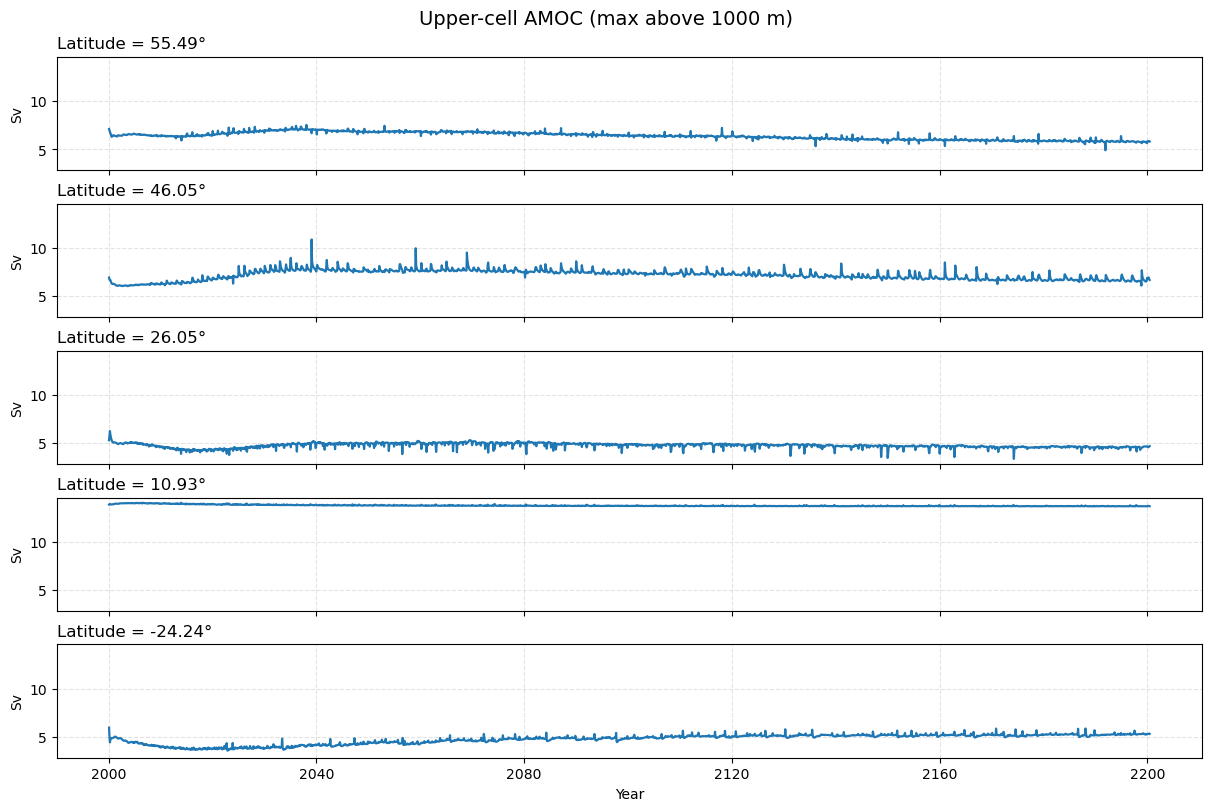

In [34]:
# --- your V-grid indices ---
J_list = [74, 110, 126, 151, 166]

vert_dim = d_entire.vert_dim

# --- Build MOC ---
v = d_entire.ds.VVEL
transport = (v * d_entire.ds.dxG * d_entire.ds.drF * d_entire.ds.hFacS).sum("i") / 1e6
psi_moc = transport.sortby(vert_dim, ascending=True).cumsum(vert_dim)

# --- Upper 1000 m ---
psi_upper = psi_moc.where(d_entire.ds.Z >= -1000, drop=True)

# --- Get latitudes (from YC at i=0) ---
yc_1d = d_entire.ds.YC.isel(i=0)
lat_list = [round(float(yc_1d.isel(j=jg).values), 2) for jg in J_list]

# --- Compute AMOC time series ---
amoc_list = [psi_upper.isel(j_g=jg).max(vert_dim) for jg in J_list]

# --- Sort so smallest latitude is at bottom ---
combined = sorted(zip(lat_list, amoc_list), key=lambda x: x[0])
lat_sorted, amoc_sorted = zip(*combined)

# --- Plot ---
n = len(lat_sorted)
fig, axes = plt.subplots(n, 1, figsize=(12, 8), sharex=True, constrained_layout=True)

# Optional common y-limits
ymin = min(float(ts.min()) for ts in amoc_sorted)
ymax = max(float(ts.max()) for ts in amoc_sorted)
pad = 0.05 * (ymax - ymin)
ylims = (ymin - pad, ymax + pad)

for ax, latv, ts in zip(axes[::-1], lat_sorted, amoc_sorted):
    ax.plot(d_entire.ds.time.values, ts.values, linewidth=1.6)
    ax.set_ylabel("Sv")
    ax.set_ylim(*ylims)
    ax.set_title(f"Latitude = {latv}°", loc="left")
    ax.grid(True, linestyle="--", alpha=0.35)

axes[-1].set_xlabel("Year")

fig.suptitle("Upper-cell AMOC (max above 1000 m)", fontsize=14)
plt.show()

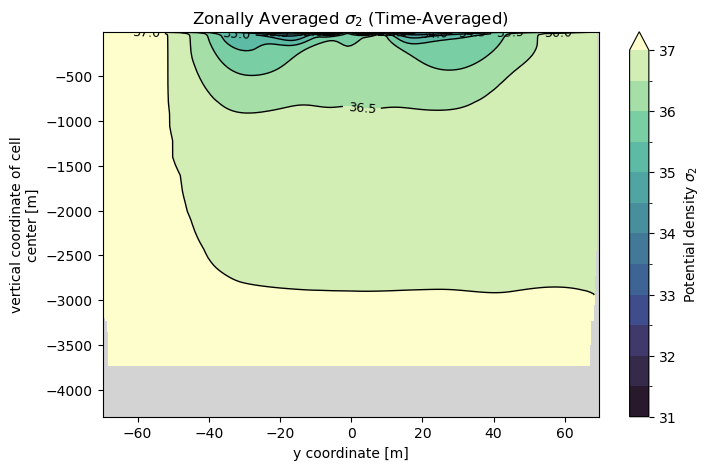

In [35]:
# Time-mean meridional section of sigma2 (zonally averaged)
fig, ax = DINOPlotter(d_last10y).plot_sigma2_sections(timemean=True)
plt.show()

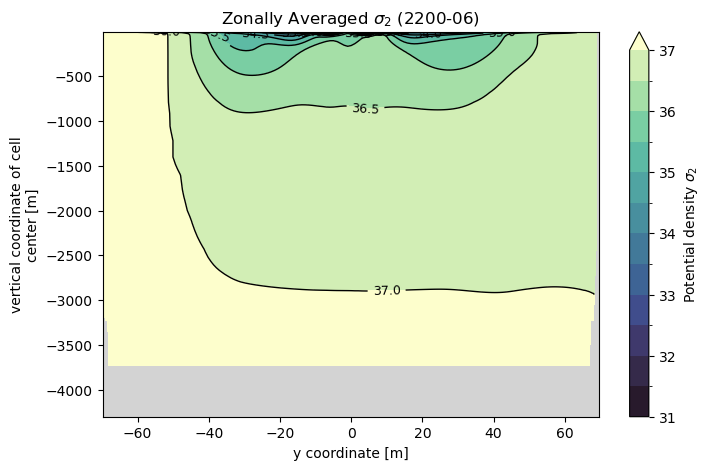

In [36]:
fig, ax = DINOPlotter(d_last10y).plot_sigma2_sections(index_show=-1, timemean=False)
plt.show()